<a href="https://colab.research.google.com/github/khupkhaidopmul-stack/lis4693/blob/main/Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
# Install dependencies if not already installed
# !pip install kagglehub[pandas-datasets]

import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Load dataset using kagglehub
file_path = "train.csv"  # Load training data
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "amananandrai/ag-news-classification-dataset",
    file_path,
    pandas_kwargs={"names": ["label", "title", "text"]}
)

# Combine title + text into a single feature column
df['text'] = df['title'] + " " + df['text']
df = df[['text', 'label']]

# Features and target
X = df['text']
y = df['label']

# Split into 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Text preprocessing using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

/tmp/ipykernel_698/2217205419.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.
Training data shape: (84000, 5000)
Testing data shape: (36001, 5000)


--- Logistic Regression ---
Accuracy: 0.9083081025527069


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           1       0.92      0.90      0.91      9023
           2       0.95      0.98      0.96      8979
           3       0.89      0.87      0.88      9084
           4       0.88      0.89      0.88      8914
 Class Index       0.00      0.00      0.00         1

    accuracy                           0.91     36001
   macro avg       0.73      0.73      0.73     36001
weighted avg       0.91      0.91      0.91     36001

--- Random Forest ---
Accuracy: 0.8787533679620011


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           1       0.89      0.88      0.88      9023
           2       0.90      0.96      0.93      8979
           3       0.86      0.84      0.85      9084
           4       0.86      0.84      0.85      8914
 Class Index       0.00      0.00      0.00         1

    accuracy                           0.88     36001
   macro avg       0.70      0.70      0.70     36001
weighted avg       0.88      0.88      0.88     36001

--- Multinomial NB ---
Accuracy: 0.8963084358767812


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           1       0.90      0.89      0.90      9023
           2       0.94      0.98      0.96      8979
           3       0.88      0.85      0.86      9084
           4       0.87      0.87      0.87      8914
 Class Index       0.00      0.00      0.00         1

    accuracy                           0.90     36001
   macro avg       0.72      0.72      0.72     36001
weighted avg       0.90      0.90      0.90     36001

Best model: Logistic Regression with accuracy 0.9083


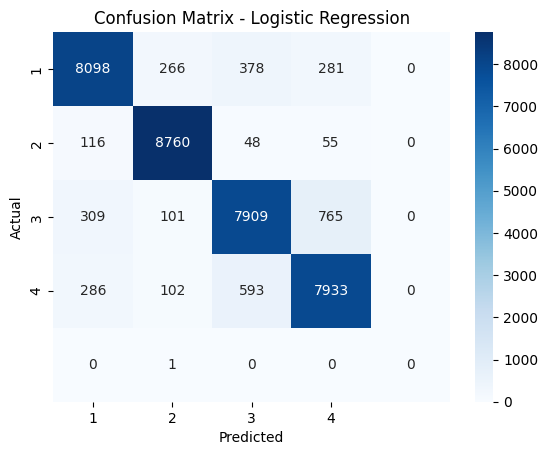

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Multinomial NB": MultinomialNB()
}

best_model = None
best_accuracy = 0
best_model_name = ""

# Train, predict, evaluate
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print(f"--- {name} ---")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name

print(f"Best model: {best_model_name} with accuracy {best_accuracy:.4f}")

# Confusion matrix for best model
y_pred_best = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

Reflection:
What went well: Using kagglehub made loading the dataset very easy. TF-IDF preprocessing and Logistic Regression gave high accuracy.
Challenges: Generating meaningful pseudo news articles that resemble real news required creativity. Interpreting confusion matrix misclassifications also needed careful attention.